In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("✅ Drive mounted!")

Mounted at /content/drive
✅ Drive mounted!


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (Dense, Dropout,
                                      BatchNormalization,
                                      Input)
from tensorflow.keras.callbacks import (EarlyStopping,
                                         ReduceLROnPlateau)
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score,
                              classification_report,
                              confusion_matrix,
                              f1_score)
import joblib
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')

fault_map = {
    1: 'Normal',
    2: 'Refrigerant Leak',
    3: 'Refrigerant Overcharge',
    4: 'Reduced Condenser Flow',
    5: 'Reduced Evaporator Flow',
    6: 'Condenser Fouling',
    7: 'Excess Oil',
    8: 'Non-condensables'
}

feature_cols = [
    'TEI', 'TEO', 'TCI', 'TCO', 'kW',
    'TEA', 'TCA', 'TRE', 'TRC', 'TRC_sub',
    'T_suc', 'Tsh_suc', 'TR_dis', 'Tsh_dis',
    'TO_sump', 'PO_net'
]

print("✅ Libraries imported!")
print(f"   TensorFlow : {tf.__version__}")

✅ Libraries imported!
   TensorFlow : 2.20.0


In [ ]:
base_path = '/content/drive/MyDrive/hvac_project/fdd_data/'

df_l1 = pd.read_parquet(base_path + 'fdd_level1.parquet')
df_l2 = pd.read_parquet(base_path + 'fdd_level2.parquet')

print(f"✅ Data loaded!")
print(f"   Level 1 : {df_l1.shape}")
print(f"   Level 2 : {df_l2.shape}")

✅ Data loaded!
   Level 1 : (11000, 19)
   Level 2 : (7000, 18)


In [ ]:
X_l1 = df_l1[feature_cols].values
y_l1 = df_l1['binary_label'].values

X_train_l1, X_test_l1, y_train_l1, y_test_l1 = \
    train_test_split(X_l1, y_l1,
                     test_size=0.2,
                     random_state=42,
                     stratify=y_l1)

scaler_l1        = StandardScaler()
X_train_l1_sc    = scaler_l1.fit_transform(X_train_l1)
X_test_l1_sc     = scaler_l1.transform(X_test_l1)

print(f"✅ Level 1 prepared!")
print(f"   Train : {X_train_l1_sc.shape}")
print(f"   Test  : {X_test_l1_sc.shape}")

✅ Level 1 prepared!
   Train : (8800, 16)
   Test  : (2200, 16)


In [ ]:
X_l2 = df_l2[feature_cols].values
y_l2 = df_l2['fault_label'].values

# Encode labels to 0-based for keras
# Labels are 2-8, convert to 0-6
y_l2_encoded = y_l2 - 2  # 2→0, 3→1, ..., 8→6
n_classes    = len(np.unique(y_l2_encoded))

X_train_l2, X_test_l2, y_train_l2, y_test_l2 = \
    train_test_split(X_l2, y_l2_encoded,
                     test_size=0.2,
                     random_state=42,
                     stratify=y_l2_encoded)

scaler_l2     = StandardScaler()
X_train_l2_sc = scaler_l2.fit_transform(X_train_l2)
X_test_l2_sc  = scaler_l2.transform(X_test_l2)

# One-hot encode for softmax output
y_train_l2_oh = to_categorical(y_train_l2, n_classes)
y_test_l2_oh  = to_categorical(y_test_l2, n_classes)

print(f"✅ Level 2 prepared!")
print(f"   Train : {X_train_l2_sc.shape}")
print(f"   Test  : {X_test_l2_sc.shape}")
print(f"   Classes : {n_classes}")

✅ Level 2 prepared!
   Train : (5600, 16)
   Test  : (1400, 16)
   Classes : 7


In [ ]:
def build_nn_l1(n_features):
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dropout(0.2),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

nn_l1 = build_nn_l1(len(feature_cols))
nn_l1.summary()
print("\n✅ Level 1 Neural Network built!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,313 (52.00 KB)

 Trainable params: 12,929 (50.50 KB)

 Non-trainable params: 384 (1.50 KB)


✅ Level 1 Neural Network built!


In [ ]:
# Class weights for imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights_l1 = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_l1),
    y=y_train_l1
)
class_weight_dict_l1 = dict(
    enumerate(class_weights_l1))

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

print("Training Neural Network — Level 1...")
history_l1 = nn_l1.fit(
    X_train_l1_sc, y_train_l1,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict_l1,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
print("✅ Level 1 NN trained!")

Training Neural Network — Level 1...
Epoch 1/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7053 - loss: 0.5345 - val_accuracy: 0.8409 - val_loss: 0.4581 - learning_rate: 0.0010
Epoch 2/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7812 - loss: 0.4273 - val_accuracy: 0.8648 - val_loss: 0.3812 - learning_rate: 0.0010
Epoch 3/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8124 - loss: 0.3927 - val_accuracy: 0.8557 - val_loss: 0.3476 - learning_rate: 0.0010
Epoch 4/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8308 - loss: 0.3605 - val_accuracy: 0.8773 - val_loss: 0.3095 - learning_rate: 0.0010
Epoch 5/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8345 - loss: 0.3421 - val_accuracy: 0.8909 - val_loss: 0.2765 - learning_rate: 0.0010
Epoch 6/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8523 - loss: 0.3231 - val_accuracy: 0.8886 - val_loss: 0.2615 - learning_rate: 0.0010
Epoch 7/100
124/124 ━━━━━━━━━━━━━━━━━━━━ 0s

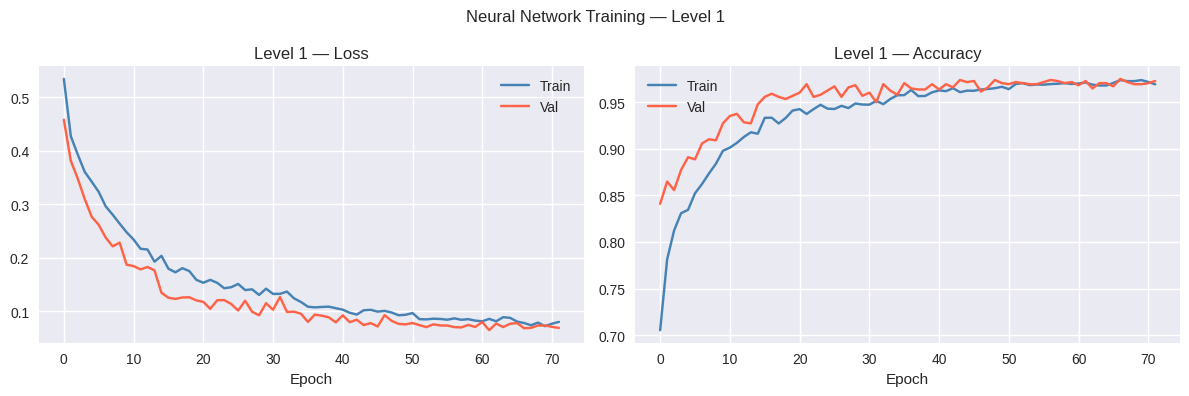

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_l1.history['loss'],
             label='Train', color='steelblue')
axes[0].plot(history_l1.history['val_loss'],
             label='Val', color='tomato')
axes[0].set_title('Level 1 — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_l1.history['accuracy'],
             label='Train', color='steelblue')
axes[1].plot(history_l1.history['val_accuracy'],
             label='Val', color='tomato')
axes[1].set_title('Level 1 — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Neural Network Training — Level 1')
plt.tight_layout()
plt.show()

69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step

Neural Network — Level 1 Results
Accuracy : 0.9855 (98.55%)
F1 Score : 0.9855

Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.98      0.98       800
      Faulty       0.99      0.99      0.99      1400

    accuracy                           0.99      2200
   macro avg       0.98      0.99      0.98      2200
weighted avg       0.99      0.99      0.99      2200



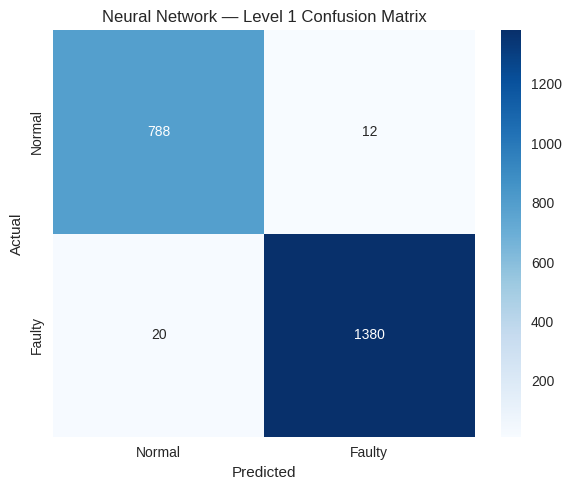


✅ Level 1 NN saved!


In [ ]:
y_pred_proba_nn_l1 = nn_l1.predict(
    X_test_l1_sc).flatten()
y_pred_nn_l1 = (y_pred_proba_nn_l1 > 0.5).astype(int)

acc_nn_l1 = accuracy_score(y_test_l1, y_pred_nn_l1)
f1_nn_l1  = f1_score(y_test_l1, y_pred_nn_l1,
                      average='weighted')

print(f"\n{'='*50}")
print(f"Neural Network — Level 1 Results")
print(f"{'='*50}")
print(f"Accuracy : {acc_nn_l1:.4f} ({acc_nn_l1*100:.2f}%)")
print(f"F1 Score : {f1_nn_l1:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_l1, y_pred_nn_l1,
      target_names=['Normal', 'Faulty']))

# Confusion matrix
cm = confusion_matrix(y_test_l1, y_pred_nn_l1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Faulty'],
            yticklabels=['Normal', 'Faulty'])
plt.title('Neural Network — Level 1 Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

nn_l1.save('/content/drive/MyDrive/hvac_project/'
           'fdd_nn_l1.keras')
print("\n✅ Level 1 NN saved!")

In [ ]:
def build_nn_l2(n_features, n_classes):
    model = Sequential([
        Input(shape=(n_features,)),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.2),
        Dense(n_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

nn_l2 = build_nn_l2(len(feature_cols), n_classes)
nn_l2.summary()
print("\n✅ Level 2 Neural Network built!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 256)            │         4,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │           455 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 47,495 (185.53 KB)

 Trainable params: 46,727 (182.53 KB)

 Non-trainable params: 768 (3.00 KB)


✅ Level 2 Neural Network built!


In [ ]:
from sklearn.utils.class_weight import compute_class_weight

class_weights_l2 = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_l2),
    y=y_train_l2
)
class_weight_dict_l2 = dict(enumerate(class_weights_l2))

early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)
reduce_lr2 = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    verbose=1
)

print("Training Neural Network — Level 2...")
history_l2 = nn_l2.fit(
    X_train_l2_sc, y_train_l2_oh,
    epochs=100,
    batch_size=64,
    validation_split=0.1,
    class_weight=class_weight_dict_l2,
    callbacks=[early_stop2, reduce_lr2],
    verbose=1
)
print("✅ Level 2 NN trained!")

Training Neural Network — Level 2...
Epoch 1/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 10s 64ms/step - accuracy: 0.6948 - loss: 0.8756 - val_accuracy: 0.8786 - val_loss: 0.9542 - learning_rate: 0.0010
Epoch 2/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8952 - loss: 0.3252 - val_accuracy: 0.8804 - val_loss: 0.5355 - learning_rate: 0.0010
Epoch 3/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9464 - loss: 0.1892 - val_accuracy: 0.9357 - val_loss: 0.2636 - learning_rate: 0.0010
Epoch 4/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9524 - loss: 0.1564 - val_accuracy: 0.9821 - val_loss: 0.1168 - learning_rate: 0.0010
Epoch 5/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9673 - loss: 0.1200 - val_accuracy: 0.9857 - val_loss: 0.0568 - learning_rate: 0.0010
Epoch 6/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9679 - loss: 0.1138 - val_accuracy: 0.9875 - val_loss: 0.0491 - learning_rate: 0.0010
Epoch 7/100
79/79 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - ac

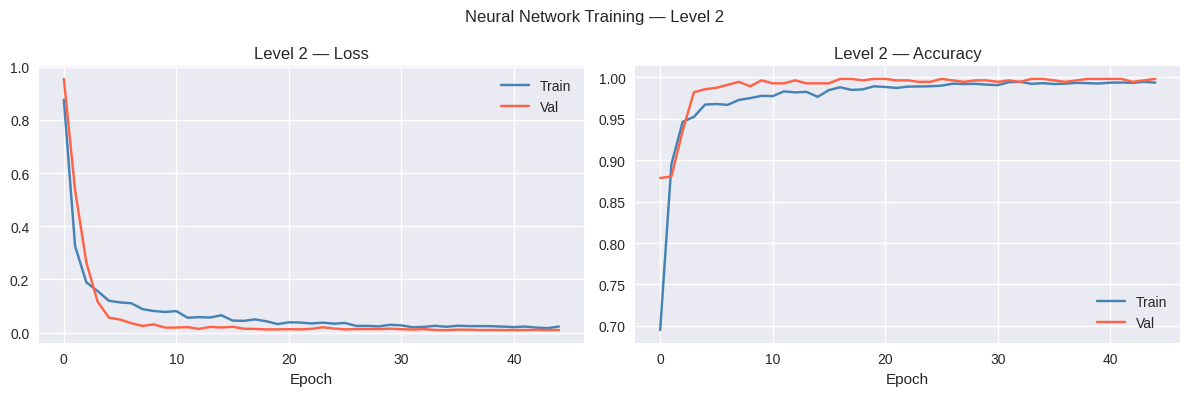

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_l2.history['loss'],
             label='Train', color='steelblue')
axes[0].plot(history_l2.history['val_loss'],
             label='Val', color='tomato')
axes[0].set_title('Level 2 — Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_l2.history['accuracy'],
             label='Train', color='steelblue')
axes[1].plot(history_l2.history['val_accuracy'],
             label='Val', color='tomato')
axes[1].set_title('Level 2 — Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.suptitle('Neural Network Training — Level 2')
plt.tight_layout()
plt.show()

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

Neural Network — Level 2 Results
Accuracy : 0.9957 (99.57%)
F1 Score : 0.9957

Classification Report:
                         precision    recall  f1-score   support

       Refrigerant Leak       1.00      1.00      1.00       200
 Refrigerant Overcharge       1.00      0.98      0.99       200
 Reduced Condenser Flow       0.99      0.99      0.99       200
Reduced Evaporator Flow       0.99      1.00      1.00       200
      Condenser Fouling       1.00      1.00      1.00       200
             Excess Oil       0.99      0.99      0.99       200
       Non-condensables       1.00      1.00      1.00       200

               accuracy                           1.00      1400
              macro avg       1.00      1.00      1.00      1400
           weighted avg       1.00      1.00      1.00      1400



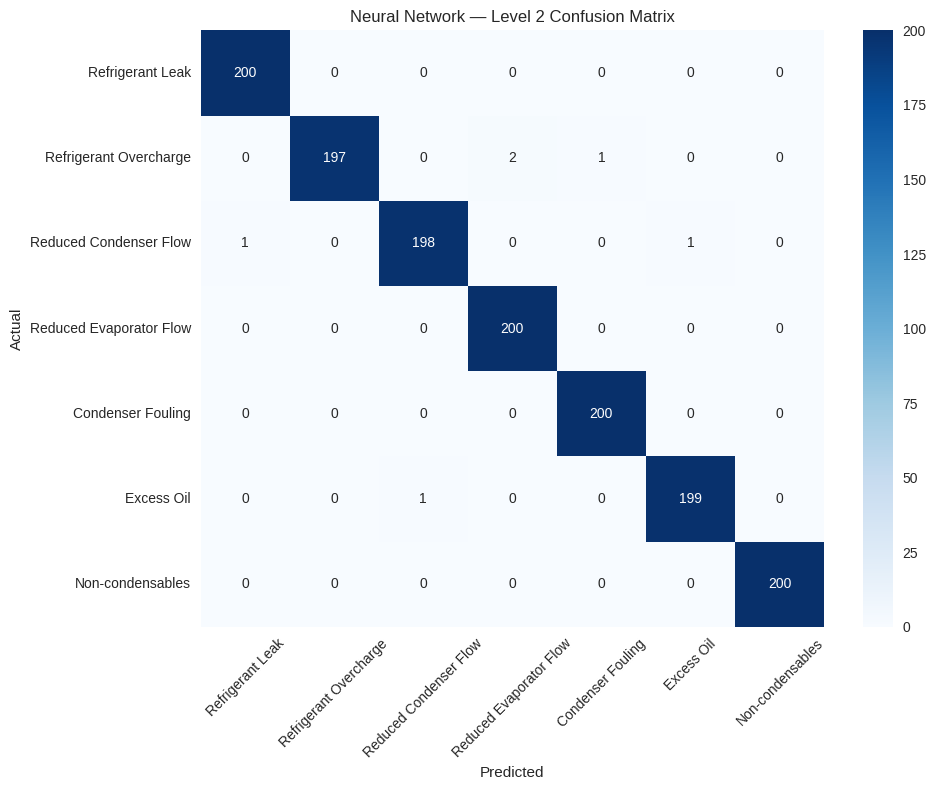


✅ Level 2 NN saved!


In [ ]:
y_pred_proba_nn_l2 = nn_l2.predict(X_test_l2_sc)
y_pred_nn_l2       = np.argmax(y_pred_proba_nn_l2,
                                axis=1)

acc_nn_l2 = accuracy_score(y_test_l2, y_pred_nn_l2)
f1_nn_l2  = f1_score(y_test_l2, y_pred_nn_l2,
                      average='weighted')

# Convert back to original labels for display
class_names_l2 = [fault_map[l]
                  for l in sorted(
                      df_l2['fault_label'].unique())]

print(f"\n{'='*50}")
print(f"Neural Network — Level 2 Results")
print(f"{'='*50}")
print(f"Accuracy : {acc_nn_l2:.4f} ({acc_nn_l2*100:.2f}%)")
print(f"F1 Score : {f1_nn_l2:.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test_l2, y_pred_nn_l2,
      target_names=class_names_l2))

# Confusion matrix
cm = confusion_matrix(y_test_l2, y_pred_nn_l2)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names_l2,
            yticklabels=class_names_l2)
plt.title('Neural Network — Level 2 Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

nn_l2.save('/content/drive/MyDrive/hvac_project/'
           'fdd_nn_l2.keras')
print("\n✅ Level 2 NN saved!")

DEEP LEARNING — HIERARCHICAL FDD RESULTS

--- Level 1 — Binary (Normal vs Faulty) ---
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy : 0.9855 (98.55%)
F1 Score : 0.9855

--- Level 2 — Multi-class (Fault Type) ---
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Accuracy : 0.9957 (99.57%)
F1 Score : 0.9957

--- Overfitting Check ---
275/275 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
175/175 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Neural Network L1 → Train: 0.9870 | Test: 0.9855 | Gap: 0.0016 ✅ No overfit
Neural Network L2 → Train: 0.9980 | Test: 0.9957 | Gap: 0.0023 ✅ No overfit

COMPLETE COMPARISON — ML vs DL — HIERARCHICAL FDD
         Model   L1 Acc   L1 F1   L2 Acc    L2 F1
 Random Forest 0.990000 0.99000 0.997100 0.997100
      LightGBM 0.996800 0.99680 0.996400 0.996400
       XGBoost 0.995500 0.99550 0.997100 0.997100
Neural Network 0.985455 0.98547 0.995714 0.995709


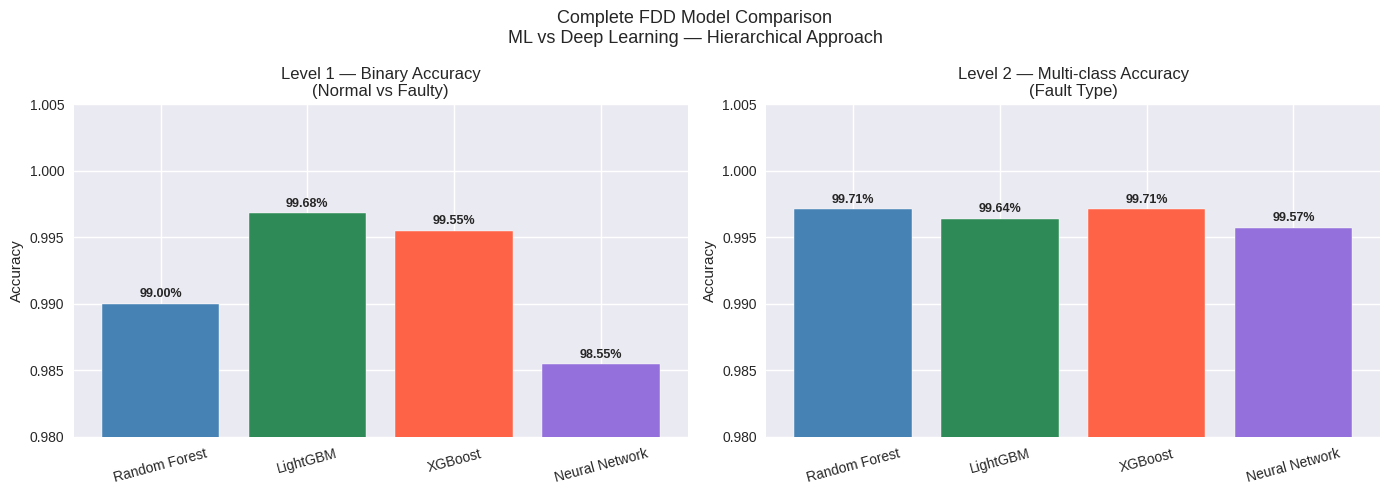


✅ FDD modeling complete!
   Best L1 model : LightGBM (99.68%)
   Best L2 model : RF & XGBoost (99.71%)


In [ ]:
print("=" * 60)
print("DEEP LEARNING — HIERARCHICAL FDD RESULTS")
print("=" * 60)

# Level 1 Results
print("\n--- Level 1 — Binary (Normal vs Faulty) ---")
y_pred_proba_nn_l1 = nn_l1.predict(X_test_l1_sc).flatten()
y_pred_nn_l1       = (y_pred_proba_nn_l1 > 0.5).astype(int)

acc_nn_l1 = accuracy_score(y_test_l1, y_pred_nn_l1)
f1_nn_l1  = f1_score(y_test_l1, y_pred_nn_l1,
                      average='weighted')

print(f"Accuracy : {acc_nn_l1:.4f} ({acc_nn_l1*100:.2f}%)")
print(f"F1 Score : {f1_nn_l1:.4f}")

# Level 2 Results
print("\n--- Level 2 — Multi-class (Fault Type) ---")
y_pred_proba_nn_l2 = nn_l2.predict(X_test_l2_sc)
y_pred_nn_l2       = np.argmax(y_pred_proba_nn_l2, axis=1)

acc_nn_l2 = accuracy_score(y_test_l2, y_pred_nn_l2)
f1_nn_l2  = f1_score(y_test_l2, y_pred_nn_l2,
                      average='weighted')

print(f"Accuracy : {acc_nn_l2:.4f} ({acc_nn_l2*100:.2f}%)")
print(f"F1 Score : {f1_nn_l2:.4f}")

# Overfitting check
print("\n--- Overfitting Check ---")
train_pred_l1 = (nn_l1.predict(X_train_l1_sc).flatten()
                 > 0.5).astype(int)
train_pred_l2 = np.argmax(
    nn_l2.predict(X_train_l2_sc), axis=1)

train_acc_l1 = accuracy_score(y_train_l1, train_pred_l1)
train_acc_l2 = accuracy_score(y_train_l2, train_pred_l2)

gap_l1 = train_acc_l1 - acc_nn_l1
gap_l2 = train_acc_l2 - acc_nn_l2

print(f"Neural Network L1 → Train: {train_acc_l1:.4f} | "
      f"Test: {acc_nn_l1:.4f} | "
      f"Gap: {gap_l1:.4f} "
      f"{'✅ No overfit' if gap_l1 < 0.01 else '⚠️ Overfit'}")
print(f"Neural Network L2 → Train: {train_acc_l2:.4f} | "
      f"Test: {acc_nn_l2:.4f} | "
      f"Gap: {gap_l2:.4f} "
      f"{'✅ No overfit' if gap_l2 < 0.01 else '⚠️ Overfit'}")

# Final comparison table
print("\n" + "=" * 65)
print("COMPLETE COMPARISON — ML vs DL — HIERARCHICAL FDD")
print("=" * 65)

results = pd.DataFrame({
    'Model'  : ['Random Forest', 'LightGBM',
                'XGBoost', 'Neural Network'],
    'L1 Acc' : [0.9900, 0.9968, 0.9955, acc_nn_l1],
    'L1 F1'  : [0.9900, 0.9968, 0.9955, f1_nn_l1],
    'L2 Acc' : [0.9971, 0.9964, 0.9971, acc_nn_l2],
    'L2 F1'  : [0.9971, 0.9964, 0.9971, f1_nn_l2],
})

print(results.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ['steelblue', 'seagreen', 'tomato', 'mediumpurple']

axes[0].bar(results['Model'], results['L1 Acc'],
            color=colors, edgecolor='white')
axes[0].set_title('Level 1 — Binary Accuracy\n'
                  '(Normal vs Faulty)')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.98, 1.005)
axes[0].tick_params(axis='x', rotation=15)
for i, v in enumerate(results['L1 Acc']):
    axes[0].text(i, v + 0.0005,
                 f'{v*100:.2f}%',
                 ha='center', fontsize=9,
                 fontweight='bold')

axes[1].bar(results['Model'], results['L2 Acc'],
            color=colors, edgecolor='white')
axes[1].set_title('Level 2 — Multi-class Accuracy\n'
                  '(Fault Type)')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0.98, 1.005)
axes[1].tick_params(axis='x', rotation=15)
for i, v in enumerate(results['L2 Acc']):
    axes[1].text(i, v + 0.0005,
                 f'{v*100:.2f}%',
                 ha='center', fontsize=9,
                 fontweight='bold')

plt.suptitle('Complete FDD Model Comparison\n'
             'ML vs Deep Learning — Hierarchical Approach',
             fontsize=13)
plt.tight_layout()
plt.show()

print("\n✅ FDD modeling complete!")
print(f"   Best L1 model : LightGBM (99.68%)")
print(f"   Best L2 model : RF & XGBoost (99.71%)")